In [1]:
import sys
import os

# FORCE project root (absolute path)
PROJECT_ROOT = r"C:\Users\Pablo Miller\proyectos\pabs-nba-analytics-dashboard"
sys.path.insert(0, PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)
print("sys.path[0]:", sys.path[0])

Project root: C:\Users\Pablo Miller\proyectos\pabs-nba-analytics-dashboard
sys.path[0]: C:\Users\Pablo Miller\proyectos\pabs-nba-analytics-dashboard


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.db import run_query, DB_PATH
from src.colors import get_primary, get_secondary
from src.metrics import add_advanced_metrics

plt.style.use("ggplot")

print("Using DB:", DB_PATH)

Using DB: C:\Users\Pablo Miller\proyectos\pabs-nba-analytics-dashboard\nba.db


In [3]:
tables = run_query("SELECT name FROM sqlite_master WHERE type='table'")
tables

,name
0,players
1,teams
2,rookies
3,season_stats
4,team_game_stats


In [4]:
seasons = run_query("SELECT DISTINCT SEASON FROM season_stats ORDER BY SEASON")
seasons

,SEASON
0,1988-89
1,1989-90
2,1990-91
3,1991-92
4,1992-93
5,1993-94
6,1994-95
7,1995-96
8,1996-97
9,1997-98


In [5]:
selected_season = seasons["SEASON"].iloc[-1]  # most recent season
selected_season

'2025-26'

In [6]:
query = """
SELECT PLAYER_NAME, TEAM_ABBREVIATION, PTS, GP
FROM season_stats
WHERE SEASON = ?
ORDER BY PTS DESC
LIMIT 10
"""

df_top_scorers = run_query(query, (selected_season,))
df_top_scorers

,PLAYER_NAME,TEAM_ABBREVIATION,PTS,GP
0,Luka Dončić,LAL,33.5,64
1,Shai Gilgeous-Alexander,OKC,31.1,68
2,Anthony Edwards,MIN,28.8,61
3,Jaylen Brown,BOS,28.7,71
4,Tyrese Maxey,PHI,28.3,70
5,Donovan Mitchell,CLE,27.9,70
6,Kawhi Leonard,LAC,27.9,65
7,Nikola Jokić,DEN,27.7,65
8,Giannis Antetokounmpo,MIL,27.6,36
9,Joel Embiid,PHI,26.9,38


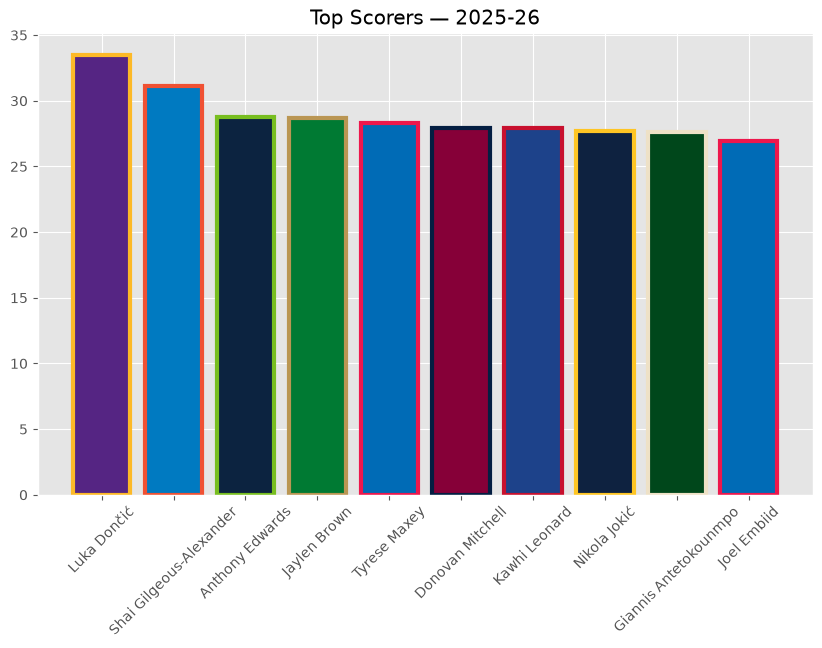

In [7]:
colors = [get_primary(t) for t in df_top_scorers["TEAM_ABBREVIATION"]]
edges = [get_secondary(t) for t in df_top_scorers["TEAM_ABBREVIATION"]]

plt.figure(figsize=(10,6))
plt.bar(df_top_scorers["PLAYER_NAME"], df_top_scorers["PTS"],
        color=colors, edgecolor=edges, linewidth=3)
plt.xticks(rotation=45)
plt.title(f"Top Scorers — {selected_season}")
plt.show()

In [8]:
query = """
SELECT TEAM_ABBREVIATION, SUM(FG3A * GP) AS TOTAL_3PA
FROM season_stats
WHERE SEASON = ?
GROUP BY TEAM_ABBREVIATION
ORDER BY TOTAL_3PA DESC
"""

df_3pa = run_query(query, (selected_season,))
df_3pa

,TEAM_ABBREVIATION,TOTAL_3PA
0,POR,3674.0
1,CHA,3591.3
2,CLE,3566.5
3,ATL,3548.8
4,GSW,3451.0
5,PHX,3376.3
6,MIL,3349.7
7,NYK,3297.6
8,MIN,3264.5
9,BOS,3254.2


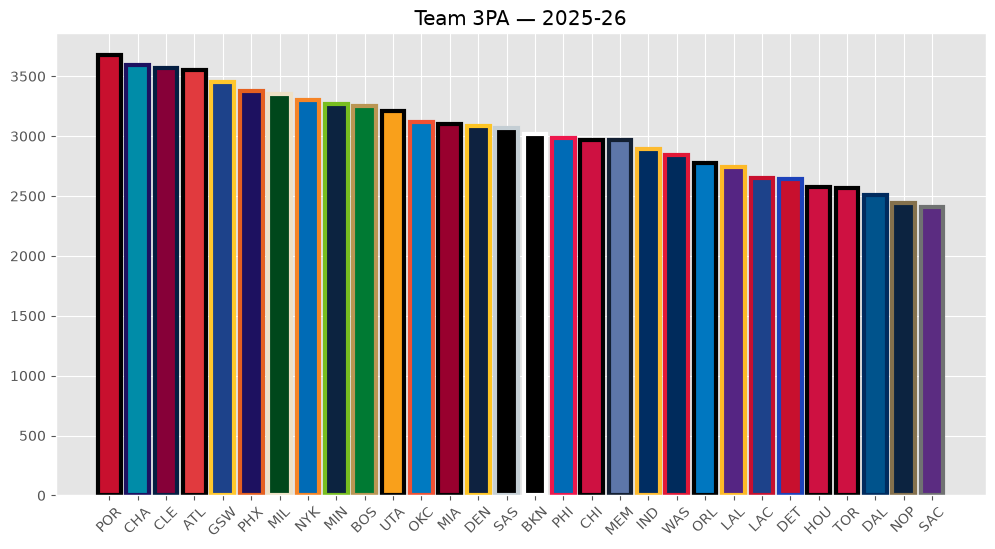

In [9]:
colors = [get_primary(t) for t in df_3pa["TEAM_ABBREVIATION"]]
edges = [get_secondary(t) for t in df_3pa["TEAM_ABBREVIATION"]]

plt.figure(figsize=(12,6))
plt.bar(df_3pa["TEAM_ABBREVIATION"], df_3pa["TOTAL_3PA"],
        color=colors, edgecolor=edges, linewidth=3)
plt.xticks(rotation=45)
plt.title(f"Team 3PA — {selected_season}")
plt.show()

In [10]:
query = """
SELECT PLAYER_NAME, TEAM_ABBREVIATION,
       PTS, FGA, FTA, FGM, FG3M, AST, TOV, MIN
FROM season_stats
WHERE SEASON = ?
AND MIN >= 30
"""

df_adv = run_query(query, (selected_season,))
df_adv = add_advanced_metrics(df_adv)
df_adv.head()

,PLAYER_NAME,TEAM_ABBREVIATION,PTS,FGA,FTA,FGM,FG3M,AST,TOV,MIN,TS_PCT,EFG_PCT,AST_TOV
0,Adama Bal,MEM,10.4,8.5,1.3,3.5,2.3,2.4,0.8,30.2,0.573192,0.547059,3.000000
1,Alperen Sengun,HOU,20.4,15.6,5.2,8.1,0.6,6.2,3.2,33.3,0.570215,0.538462,1.937500
2,Amen Thompson,HOU,18.3,13.2,4.9,7.1,0.3,5.3,2.4,37.4,0.595858,0.549242,2.208333
3,Andersson Garcia,UTA,5.2,5.8,1.8,1.8,0.2,2.8,1.4,33.8,0.394417,0.327586,2.000000
4,Andrew Nembhard,IND,16.9,13.2,4.1,5.8,1.9,7.7,2.4,31.3,0.563183,0.511364,3.208333


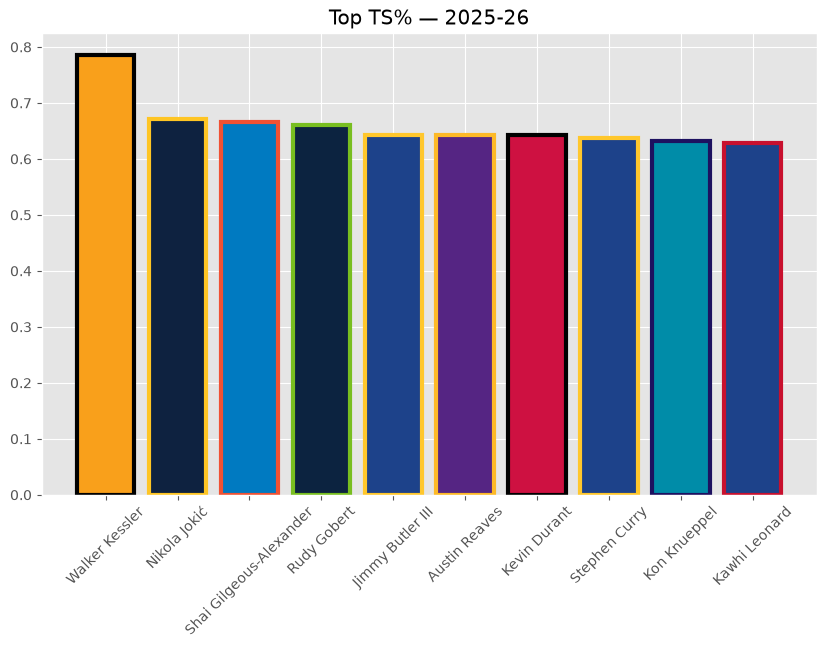

In [11]:
df_ts = df_adv.sort_values("TS_PCT", ascending=False).head(10)

colors = [get_primary(t) for t in df_ts["TEAM_ABBREVIATION"]]
edges = [get_secondary(t) for t in df_ts["TEAM_ABBREVIATION"]]

plt.figure(figsize=(10,6))
plt.bar(df_ts["PLAYER_NAME"], df_ts["TS_PCT"],
        color=colors, edgecolor=edges, linewidth=3)
plt.xticks(rotation=45)
plt.title(f"Top TS% — {selected_season}")
plt.show()